# Build the best associative memory you can, with scaling laws

You have **10¹³ flops** and **3 screening rounds** to decide how to spend them.
Then you get **one shot** at a final "hero" run. No do-overs.

### The model
$\hat p(\cdot\mid x) = \mathrm{softmax}(W e_x)$, with $W \in \mathbb{R}^{512\times n}$ and no bias.
The output dimension is fixed at $d=512$; $e_x$ is a random unit vector attached to token $x$.
So the model has $N = 512n$ parameters and **its only job is to memorise $p(y\mid x)$ for as many $x$ as it can.**

### The data
* inputs: $p(x)\propto x^{-1.2}$, cut off at $p=10^{-14}$ — that is a vocabulary of $1.1\times10^{11}$ tokens,
  so you will never see most of them, and the ones you do see follow a brutally heavy tail;
* outputs: for each $x$, a fixed random distribution over the 512 classes whose effective
  support $e^{H(x)}$ averages 16.

### What you control
| knob | notes |
|---|---|
| `n` — the width | the *only* size knob. $N = 512n$ |
| `steps` (or `c`, the flops per run) | tokens $D = 64\times$ steps |
| `lr` — peak learning rate | cosine decay to `lr/10`, no warmup |

Fixed by the rules: Adam, batch 64, cross-entropy loss, cosine schedule.

### Flop accounting
Training costs $6ND$; every evaluation pass costs $2NM$ and **also counts**. Both are billed
automatically — you cannot accidentally overspend, the library refuses instead.

### Your deliverable
A recipe, the hero-run parameters, the loss you **predicted before running it**, and the loss you got.

## 0. Setup

Run `uv run assocmem-prepare` once in a terminal first (it builds ~250 MB of cached data, ~1 min).

Everything you do lives in `runs/<your-name>/` and survives a kernel restart — including the
flops you have already spent. `lab.reset(confirm=True)` starts over from scratch.

In [1]:
%config InlineBackend.figure_formats = ['retina']
from assocmem import Lab, Sweep, BudgetError
from assocmem.plots import plot_summary

lab = Lab("me", budget=1e13, rounds=3)
print(f"irreducible loss (mean conditional entropy) = {lab.l_inf:.4f} nats")
print(f"predicting uniform would give log(512)      = 6.2383 nats")

lab 'me':  0 / 1e+13 flops spent (0.0%),  1e+13 left  |  rounds 0/3  |  0 runs recorded
irreducible loss (mean conditional entropy) = 2.4678 nats
predicting uniform would give log(512)      = 6.2383 nats


## 1. How the API works

A `Sweep` is a cartesian product. Give the time axis as `c` (flops per run — steps are
derived from `n`) or as `steps` directly. `c` is what you want for scaling laws, because it
puts every run in the sweep at **equal compute**:

```python
Sweep(c=[4e9, 1.2e10], n=[64, 128, 256], lr=[0.03, 0.06])   # 2*3*2 = 12 runs
Sweep(...) + Sweep(...)                                     # concatenate, for irregular designs
```

Three rules to internalise:

1. **`sweep.estimate(lab)` is free.** Always price a sweep before running it.
2. **`lab.run_round(...)` spends one of your three rounds**, however many configs are in it.
   So put everything you want to learn *simultaneously* into one sweep.
3. **Re-running an identical config is free** and does not burn a round — results are cached.
   And `smoke=True` runs your sweep at 1% of the steps to check it works, for ~1% of the cost
   and no round.

In [2]:
s = Sweep(c=[4e9, 1.2e10], n=[64, 128, 256, 512], lr=[0.0125, 0.025, 0.05, 0.1, 0.2])
s.estimate(lab)   # free: prints cost, share of budget, wall-clock estimate, and what it would cut

40 runs in 8 groups  ->  3.6e+11 flops, ~5 s
  3.6% of the 1e+13 budget; 1e+13 left (3 rounds)
  FITS
  by C rung: 1.2e+10: 2.6e+11 (20 runs),  4e+09: 1e+11 (20 runs)


Estimate(sweep=Sweep(40 runs, 8 groups, C rungs ['4e+09', '1.2e+10']), lab=<assocmem.lab.Lab object at 0x10fdb5280>, eval_tokens=4096)

In [3]:
# the library refuses instead of overspending -- and tells you what to cut
try:
    lab.run_round("much too big", Sweep(c=[3e12], n=[500, 1000, 2000], lr=[0.02, 0.04, 0.08]))
except BudgetError as e:
    print(e)

that sweep would cost 2.704e+13 flops but only 1e+13 remain (2.70x too big).
Options:
  - cut the lr grid from 3 to 1 values
  - or scale every C down by 0.37x
  cost breakdown by rung: C=3e+12: 2.7e+13


## 2. Round 1 — where is the learning rate, and what does an IsoFLOP curve look like?

At fixed compute `c`, sweeping `n` trades **capacity against data**: a wider model memorises
more per token seen, but takes fewer steps for the same flops. The loss-vs-`n` curve therefore
has a minimum — that is the *IsoFLOP optimum* $n^*(C)$, and it is the thing you are going to
extrapolate.

Round 1 should be **cheap and wide**: you do not know where `lr*` is yet, so bracket it
generously (a factor of ~16 from end to end), and use two cheap compute rungs so you get your
first two points on the $n^*(C)$ curve for free.

The sweep below is a reasonable starting point. Run it as-is the first time.

In [4]:
s1 = Sweep(c=[4e9, 1.2e10],
           n=[64, 128, 256, 512],
           lr=[0.0125, 0.025, 0.05, 0.1, 0.2])

lab.run_round("R1 lr landscape", s1, smoke=True, plot=False)   # free of rounds: does it run?

round 'R1 lr landscape': 40 runs in 4 groups, 5.91e+10 flops, ~2 s   [SMOKE]


  [1/4] n=   64 steps=    10  best lr=0.2 loss=5.1867


  [2/4] n=  128 steps=    10  best lr=0.2 loss=5.1761


  [3/4] n=  256 steps=    10  best lr=0.1 loss=5.1324


  [4/4] n=  512 steps=    10  best lr=0.1 loss=5.1415

best this round: n=256 steps=10 lr=0.1  ->  loss 5.1324   (2 s)
lab 'me':  5.914e+10 / 1e+13 flops spent (0.6%),  9.941e+12 left  |  rounds 0/3  |  0 runs recorded


Results(rows=[{'key': 'n64-s10-lr0.0125-i0-z0', 'round': 1, 'round_name': 'R1 lr landscape', 'c': 4000000000.0, 'n': 64, 'steps': 10, 'tokens': 640, 'lr': 0.0125, 'init': 0.0, 'seed': 0, 'loss': 6.100212097167969, 'flops': 125829120.0, 'smoke': True}, {'key': 'n64-s10-lr0.025-i0-z0', 'round': 1, 'round_name': 'R1 lr landscape', 'c': 4000000000.0, 'n': 64, 'steps': 10, 'tokens': 640, 'lr': 0.025, 'init': 0.0, 'seed': 0, 'loss': 5.966727256774902, 'flops': 125829120.0, 'smoke': True}, {'key': 'n64-s10-lr0.05-i0-z0', 'round': 1, 'round_name': 'R1 lr landscape', 'c': 4000000000.0, 'n': 64, 'steps': 10, 'tokens': 640, 'lr': 0.05, 'init': 0.0, 'seed': 0, 'loss': 5.717496395111084, 'flops': 125829120.0, 'smoke': True}, {'key': 'n64-s10-lr0.1-i0-z0', 'round': 1, 'round_name': 'R1 lr landscape', 'c': 4000000000.0, 'n': 64, 'steps': 10, 'tokens': 640, 'lr': 0.1, 'init': 0.0, 'seed': 0, 'loss': 5.335479736328125, 'flops': 125829120.0, 'smoke': True}, {'key': 'n64-s10-lr0.2-i0-z0', 'round': 1, 'ro

round 'R1 lr landscape': 40 runs in 8 groups, 3.6e+11 flops, ~5 s


  [1/8] n=  256 steps=    79  best lr=0.1 loss=4.2428


  [2/8] n=   64 steps=   318  best lr=0.1 loss=4.0641


  [3/8] n=  128 steps=   159  best lr=0.1 loss=4.0942


  [4/8] n=  512 steps=    40  best lr=0.1 loss=4.4733


  [5/8] n=  256 steps=   238  best lr=0.1 loss=3.9516


  [6/8] n=  512 steps=   119  best lr=0.05 loss=4.0982


  [7/8] n=   64 steps=   954  best lr=0.05 loss=3.9309


  [8/8] n=  128 steps=   477  best lr=0.05 loss=3.9019

best this round: n=128 steps=477 lr=0.05  ->  loss 3.9019   (3 s)
lab 'me':  4.193e+11 / 1e+13 flops spent (4.2%),  9.581e+12 left  |  rounds 1/3  |  40 runs recorded


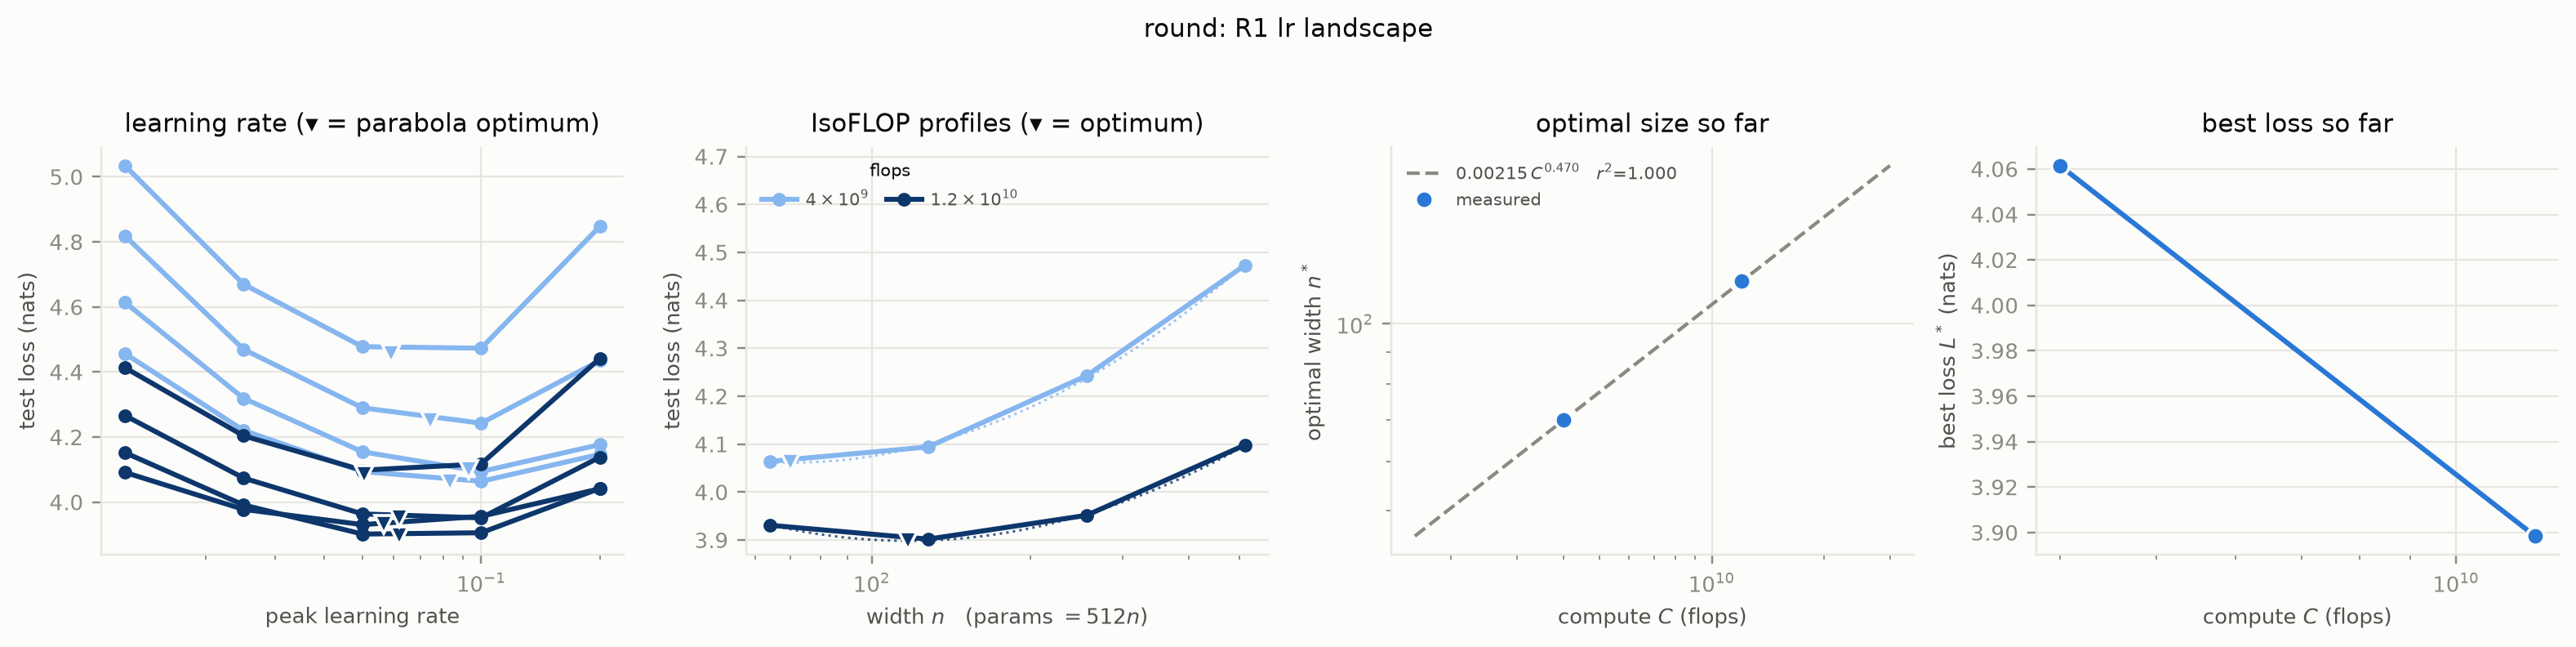

In [5]:
r1 = lab.run_round("R1 lr landscape", s1)

**Read the plots.** Before moving on, answer these from the figure:

1. Is `lr*` inside your grid, or pinned at an edge? If it is at an edge you have measured a
   *bound*, not an optimum, and the loss at that rung is an over-estimate.
2. Does `lr*` depend on `n`, or only on `c`? (Compare cells at the same `c` but different `n`.)
3. How **flat** is the IsoFLOP minimum? If being 2× wrong in `n` costs 0.03 nats but being 2×
   wrong in `lr` costs 0.06, you know which one deserves round 3.
4. `lab.fit()` needs ≥3 widths at ≥2 compute rungs. You already have that — try it.

fitted on 2 IsoFLOP rungs (4e+09 -> 1.2e+10 flops)
  n*(C)  = 0.002147 * C^0.4699          r2=1.0000
  lr*(C) = 32.61 * C^-0.2700          from 2 bracketed lr sweep(s)
  L*(C)  = 2.4678 + 14.31 * C^-0.0994   r2=1.0000   (L_inf pinned to the eval set's mean entropy)
  L*(C)  = 2.4678 + 14.31 * C^-0.0994   (3-param, L_inf free)
  => N ~ C^0.470, D ~ C^0.530


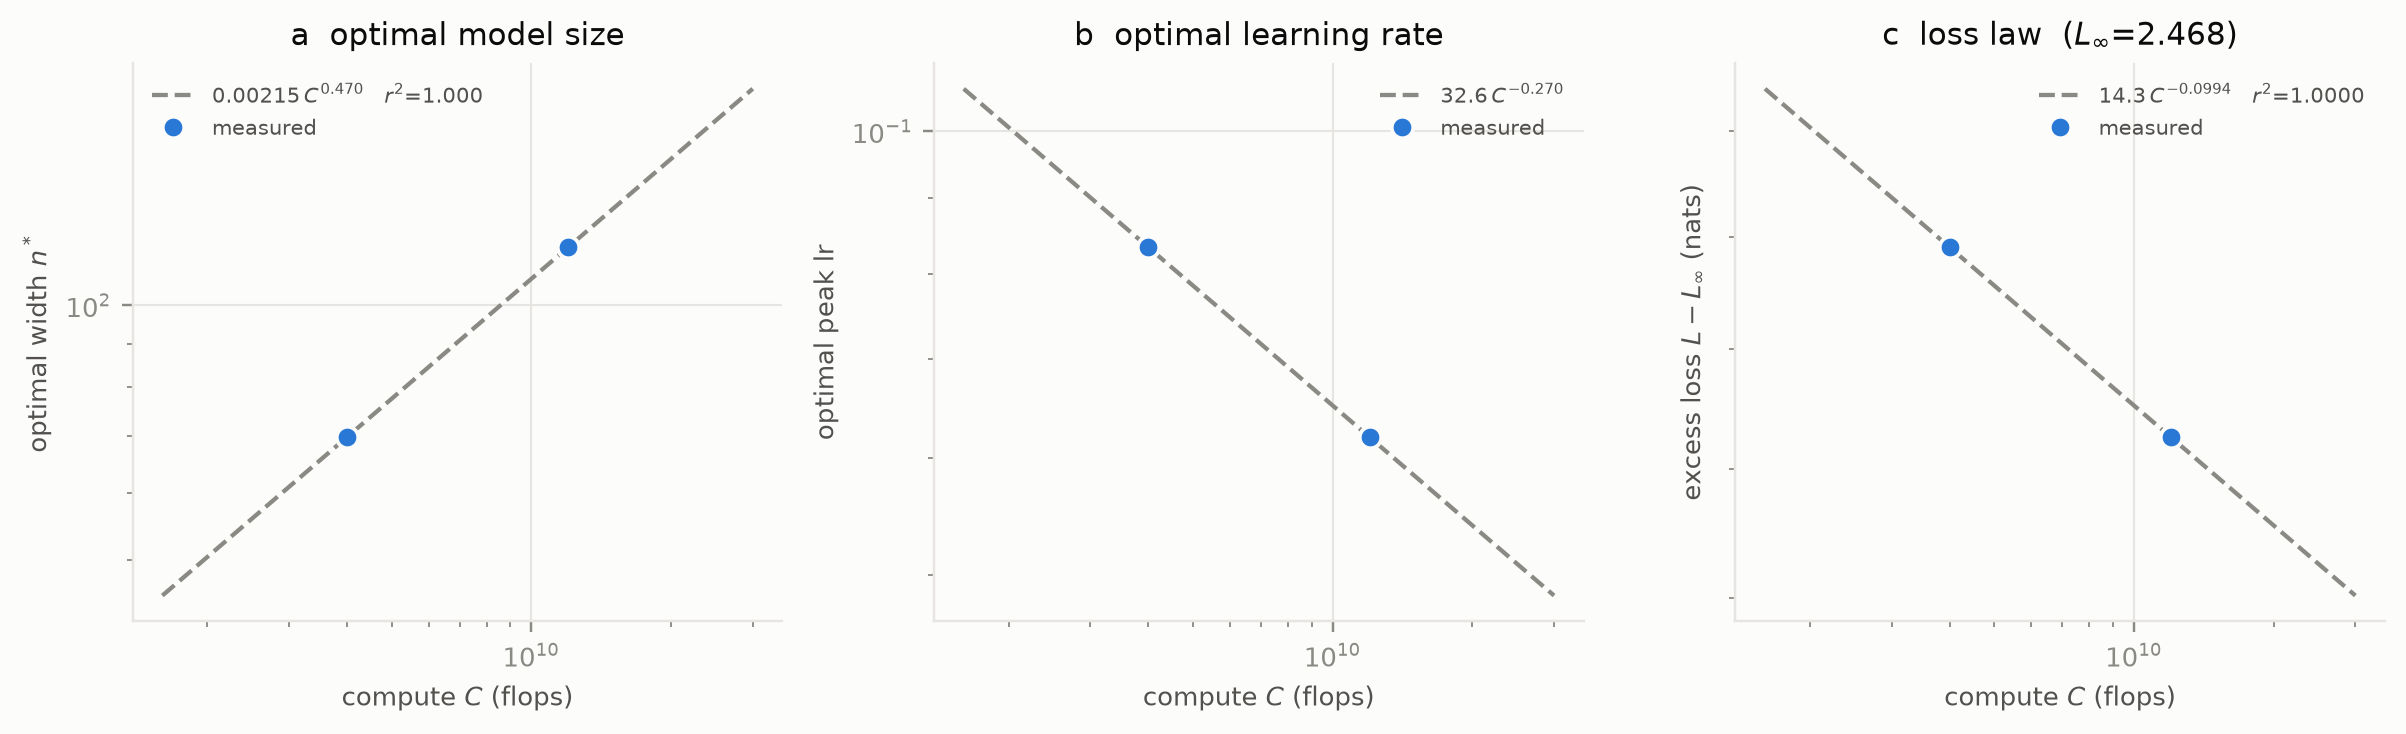


recipe this law suggests for C = 1e12: {'n': 936, 'steps': 5434, 'lr': 0.01878712267230772, 'tokens': 347776, 'params': 479232, 'predicted_loss': 3.3864807316698027}


In [6]:
laws1 = lab.fit()
print("\nrecipe this law suggests for C = 1e12:", laws1.recipe(1e12))

## 3. Round 2 — extend the ladder

You are going to extrapolate ~20× beyond your most expensive rung, so **span matters more
than density**: rungs 3× apart teach you far more about the exponent than rungs 1.2× apart.

But cost scales with the rung: a profile of $k$ widths at compute $C$ costs $kC$. So the
arithmetic is unforgiving — spend few configs at expensive rungs, many at cheap ones.

⚠️ The defaults below are deliberately mediocre. **Edit them.** Think about:
* how high a rung can you afford, given you still need round 3 *and* a hero run?
* how many lrs do you need here, now that you know something about `lr*`?
* `laws1.lr(c)` will predict a learning rate for you — do you trust it?

In [7]:
# ---------------- EDIT ME ----------------
s2 = Sweep(c=[4e10, 1.2e11],
           n=[128, 256, 512, 1024],
           lr=[0.025, 0.05])
# ----------------------------------------
s2.estimate(lab)

16 runs in 8 groups  ->  1.31e+12 flops, ~12 s
  13.1% of the 1e+13 budget; 9.58e+12 left (2 rounds)
  FITS
  by C rung: 1.2e+11: 9.76e+11 (8 runs),  4e+10: 3.36e+11 (8 runs)


Estimate(sweep=Sweep(16 runs, 8 groups, C rungs ['4e+10', '1.2e+11']), lab=<assocmem.lab.Lab object at 0x10fdb5280>, eval_tokens=4096)

round 'R2 extend the ladder': 16 runs in 8 groups, 1.31e+12 flops, ~12 s


  [1/8] n=  512 steps=   397  best lr=0.05 loss=3.7874


  [2/8] n=  128 steps=  1589  best lr=0.05 loss=3.7560


  [3/8] n=  256 steps=   795  best lr=0.05 loss=3.7349


  [4/8] n= 1024 steps=   199  best lr=0.05 loss=3.9182


  [5/8] n=  128 steps=  4768  best lr=0.025 loss=3.6858


  [6/8] n=  256 steps=  2384  best lr=0.025 loss=3.6230


  [7/8] n=  512 steps=  1192  best lr=0.05 loss=3.6194


  [8/8] n= 1024 steps=   596  best lr=0.05 loss=3.6865

best this round: n=512 steps=1192 lr=0.05  ->  loss 3.6194   (8 s)
lab 'me':  1.731e+12 / 1e+13 flops spent (17.3%),  8.269e+12 left  |  rounds 2/3  |  56 runs recorded


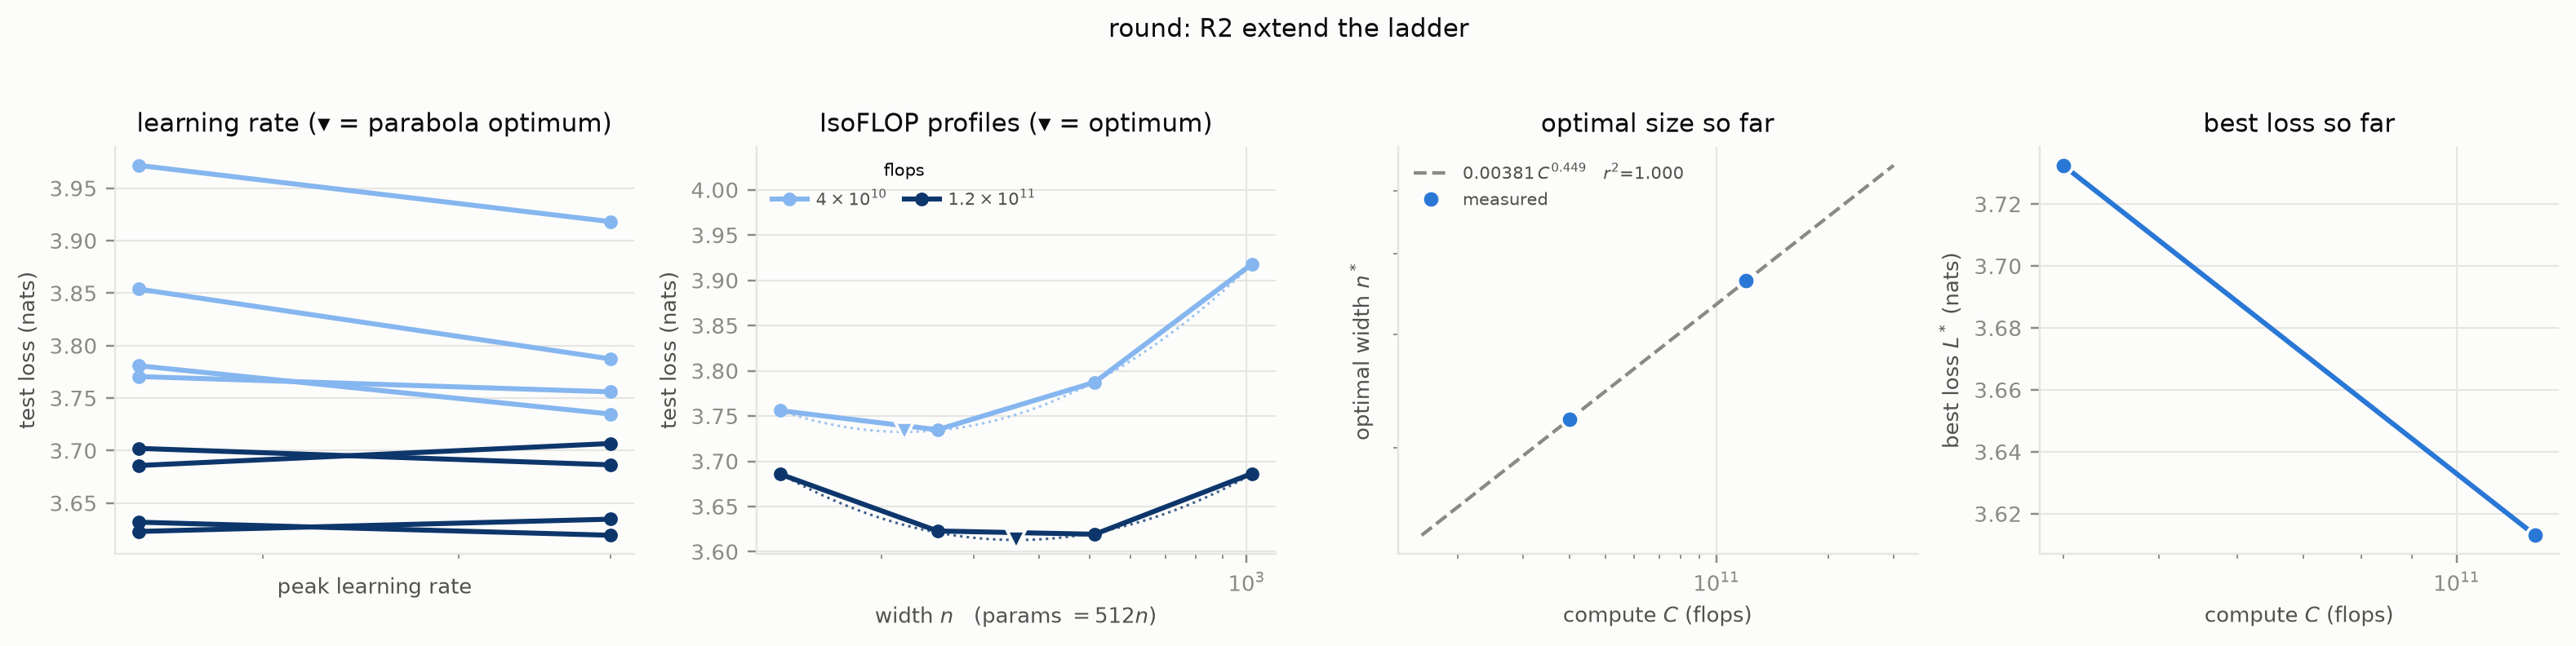

fitted on 4 IsoFLOP rungs (4e+09 -> 1.2e+11 flops)
  n*(C)  = 0.0014 * C^0.4892          r2=0.9991
  lr*(C) = 32.61 * C^-0.2700          from 2 bracketed lr sweep(s)
  L*(C)  = 2.4678 + 14.83 * C^-0.1010   r2=0.9999   (L_inf pinned to the eval set's mean entropy)
  L*(C)  = 2.1998 + 11.92 * C^-0.0841   (3-param, L_inf free)
  => N ~ C^0.489, D ~ C^0.511
  note: rung C=1.2e+11 was trained at lr=0.05 vs lr*=0.0333; L* corrected by -0.0175


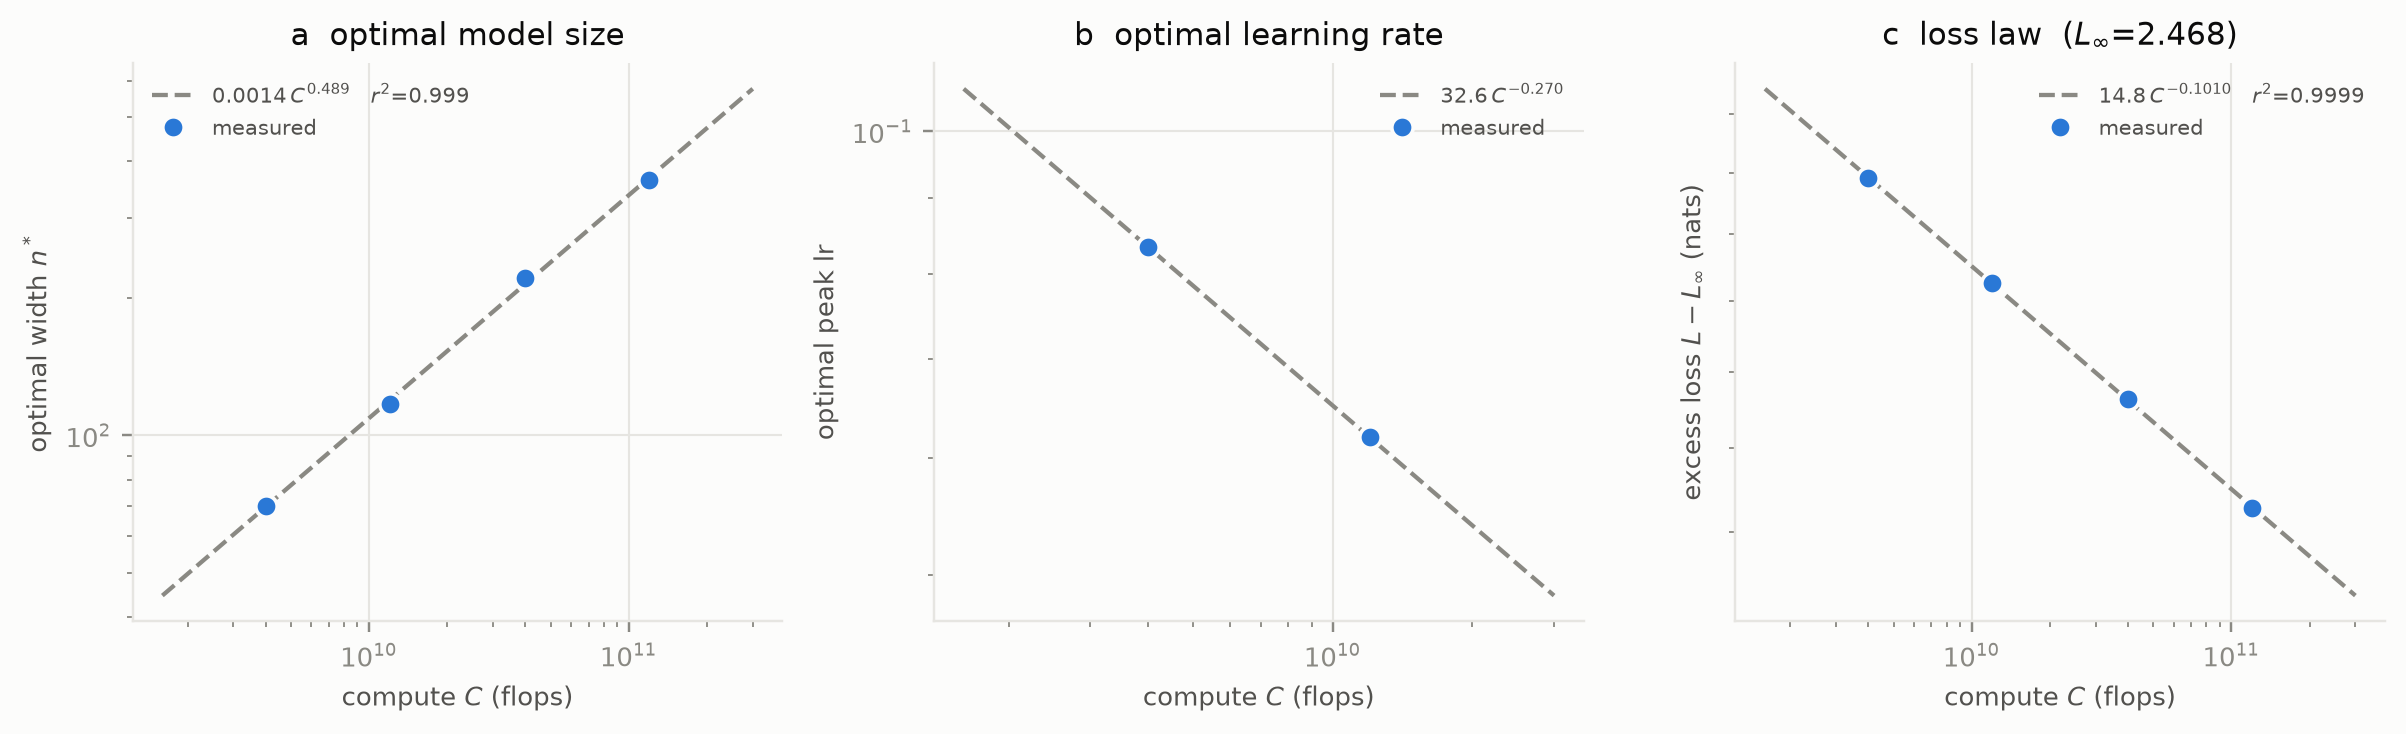

In [8]:
r2 = lab.run_round("R2 extend the ladder", s2)
laws2 = lab.fit()

## 4. Round 3 — spend it on your biggest uncertainty

You have one round left. Two things are still uncertain, and they are not equally important:

* **the exponent of $n^*(C)$** — but the IsoFLOP minimum is flat, so guessing `n` wrong by 30%
  is nearly free;
* **`lr*` at the hero scale** — where the penalty for being wrong is much steeper, and which
  you have only measured at small scale.

A useful trick: at every rung so far, `lr*` was the same for *every* `n`. If that holds, you
can sweep `lr` at one width and reuse it at the others, which buys you a full IsoFLOP profile
**and** an lr parabola at your top rung for the price of ~5 runs.

⚠️ Again, the default below is mediocre — it has no lr sweep at all, so `lab.fit()` will have
to extrapolate `lr*` blind. **Fix that.**

In [9]:
# ---------------- EDIT ME ----------------
c3 = 3e11
s3 = Sweep(c=[c3], n=[280, 560, 1120], lr=[laws2.lr(c3)])
# hint: + Sweep(c=[c3], n=[560], lr=[laws2.lr(c3) / 1.75, laws2.lr(c3) * 1.75])
# ----------------------------------------
s3.estimate(lab)

3 runs in 3 groups  ->  9.08e+11 flops, ~7 s
  9.1% of the 1e+13 budget; 8.27e+12 left (1 rounds)
  FITS


Estimate(sweep=Sweep(3 runs, 3 groups, C rungs ['3e+11']), lab=<assocmem.lab.Lab object at 0x10fdb5280>, eval_tokens=4096)

round 'R3 top rung': 3 runs in 3 groups, 9.08e+11 flops, ~7 s


  [1/3] n= 1120 steps=  1362  best lr=0.026 loss=3.5452


  [2/3] n=  280 steps=  5450  best lr=0.026 loss=3.5539


  [3/3] n=  560 steps=  2725  best lr=0.026 loss=3.5189

best this round: n=560 steps=2725 lr=0.026  ->  loss 3.5189   (6 s)
lab 'me':  2.64e+12 / 1e+13 flops spent (26.4%),  7.36e+12 left  |  rounds 3/3  |  59 runs recorded


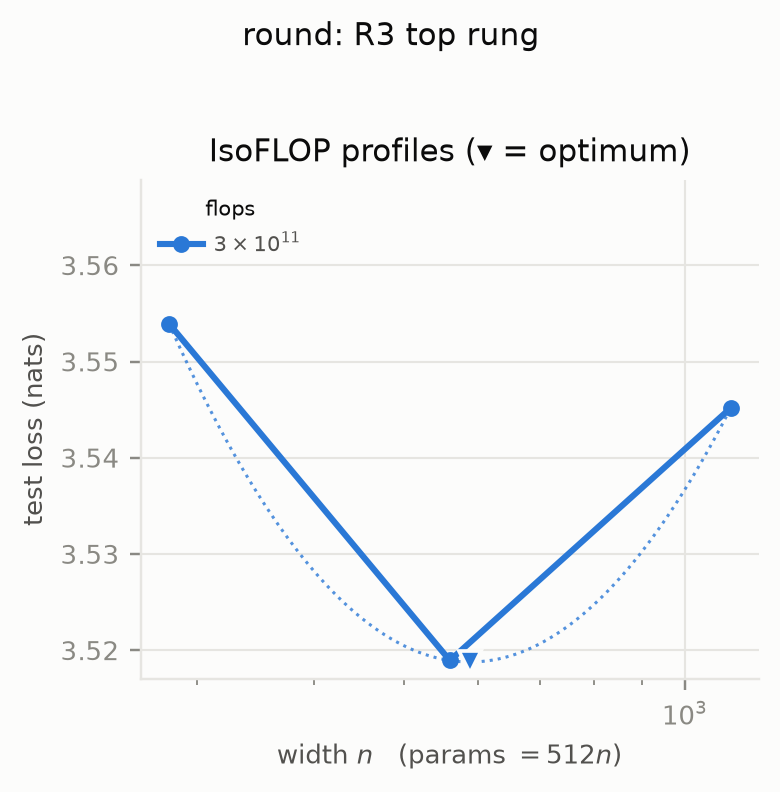

In [10]:
r3 = lab.run_round("R3 top rung", s3)

## 5. Fit the laws

`lab.fit()` does three things: takes the per-rung IsoFLOP optimum $(n^*, L^*)$ from a parabola
in $\log n$, fits power laws $n^*(C)$, $\mathrm{lr}^*(C)$ and $L^*(C) = L_\infty + AC^{-\alpha}$,
and corrects any rung whose best `lr` sat away from the fitted `lr*` (it tells you when it does).

Check the $r^2$ values and the residuals. If a law is not clean, say so in your write-up — an
honest error bar is worth more than a confident wrong number.

fitted on 5 IsoFLOP rungs (4e+09 -> 3e+11 flops)
  n*(C)  = 0.001282 * C^0.4929          r2=0.9994
  lr*(C) = 32.61 * C^-0.2700          from 2 bracketed lr sweep(s)
  L*(C)  = 2.4678 + 13.64 * C^-0.0973   r2=0.9983   (L_inf pinned to the eval set's mean entropy)
  L*(C)  = 2.8306 + 24.92 * C^-0.1361   (3-param, L_inf free)
  => N ~ C^0.493, D ~ C^0.507
  note: rung C=1.2e+11 was trained at lr=0.05 vs lr*=0.0333; L* corrected by -0.0175


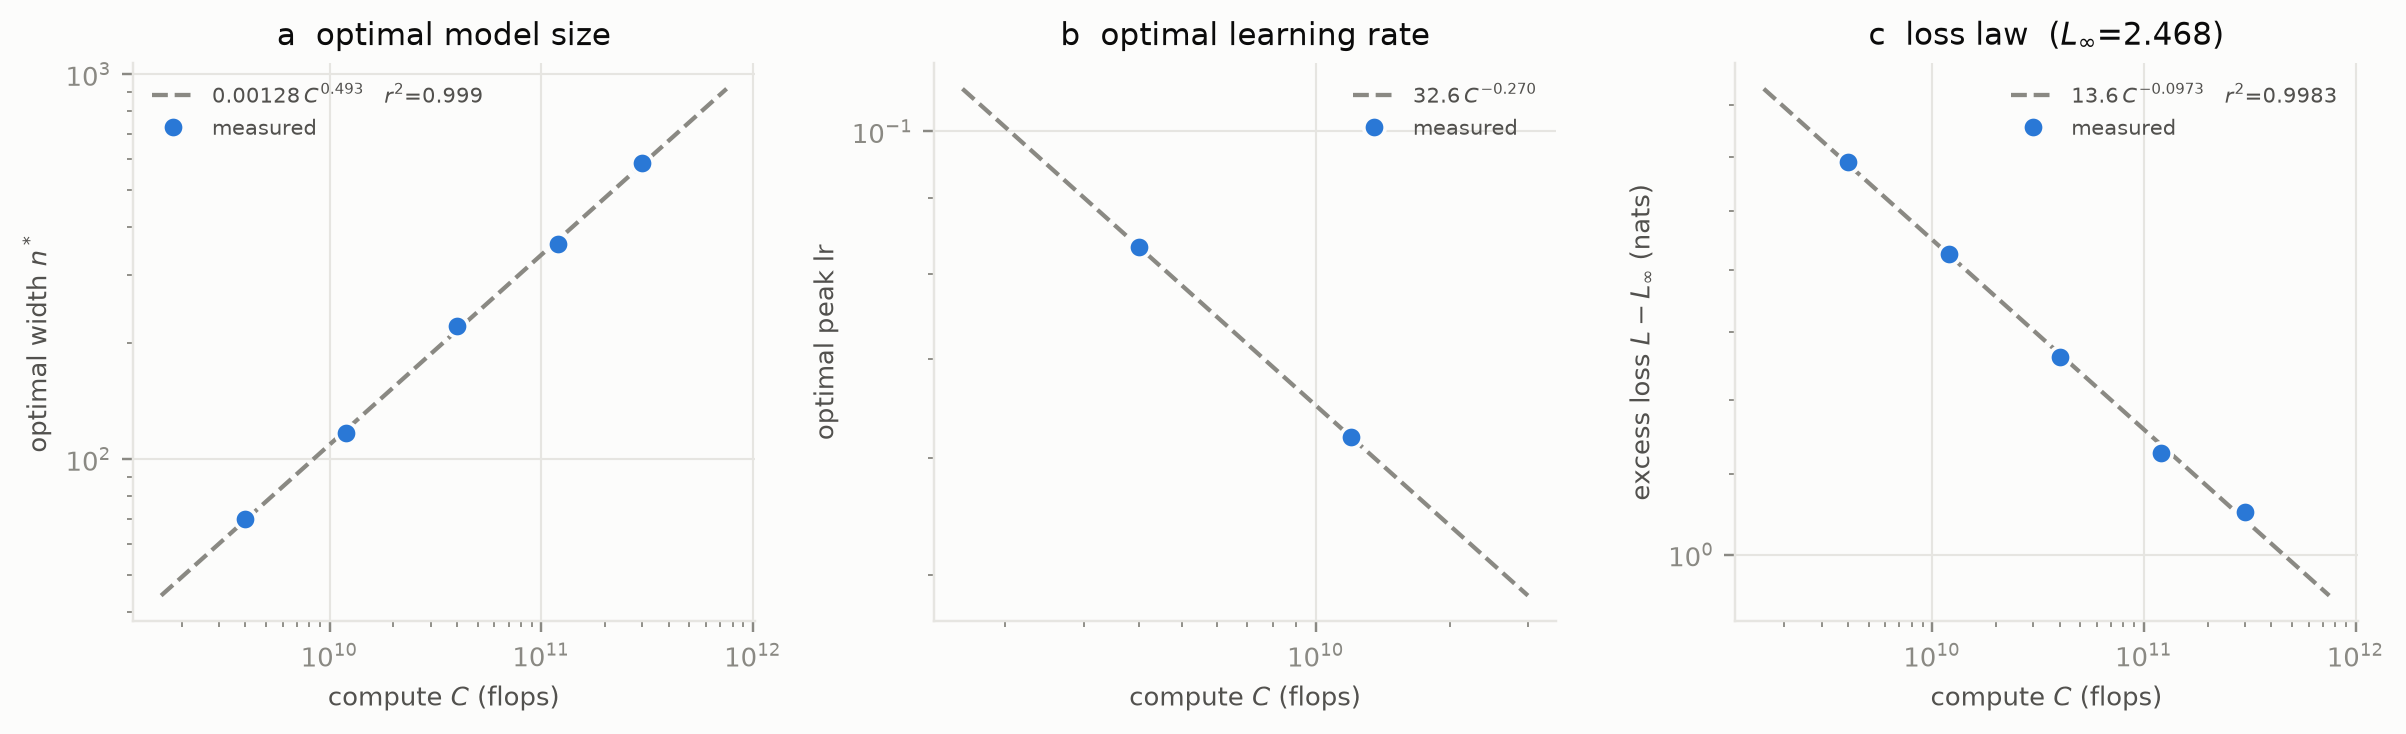


----------------------------------------------------------------------
recipe at the compute you have left: {'n': 2824, 'steps': 13257, 'lr': 0.010960564149499969, 'tokens': 848448, 'params': 1445888, 'predicted_loss': 3.2305956121517405}


In [11]:
laws = lab.fit()
print("\n" + "-" * 70)
print("recipe at the compute you have left:", laws.recipe(lab.remaining))

## 6. The hero run — commit your prediction first

`lab.hero(laws)` sizes the run to every flop you have left, **prints the loss it predicts**,
and only then trains. That ordering is the point: a scaling law that you consult after seeing
the answer has taught you nothing.

You get one call. It will refuse a second.

HERO RECIPE at C=6.971e+12 (+3.69e+11 for evals)
  n = 2752  (1,409,024 params) | steps = 12884  (824,576 tokens) | lr = 0.01112 -> 0.001112 cosine
  PREDICTED LOSS = 3.2346 nats   (3.2758 from the 3-param fit)



=== HERO RESULT ===
  ACTUAL loss   = 3.2765 nats  (65536 held-out tokens)
  PREDICTED     = 3.2346          error +0.0419
  cross-checks  : 3.2646 (sampled-y CE), 3.2756 (independent eval set)
  irreducible   = 2.4632   -> excess 0.8133 nats
lab 'me':  9.98e+12 / 1e+13 flops spent (99.8%),  1.991e+10 left  |  rounds 3/3  |  59 runs recorded  |  HERO DONE


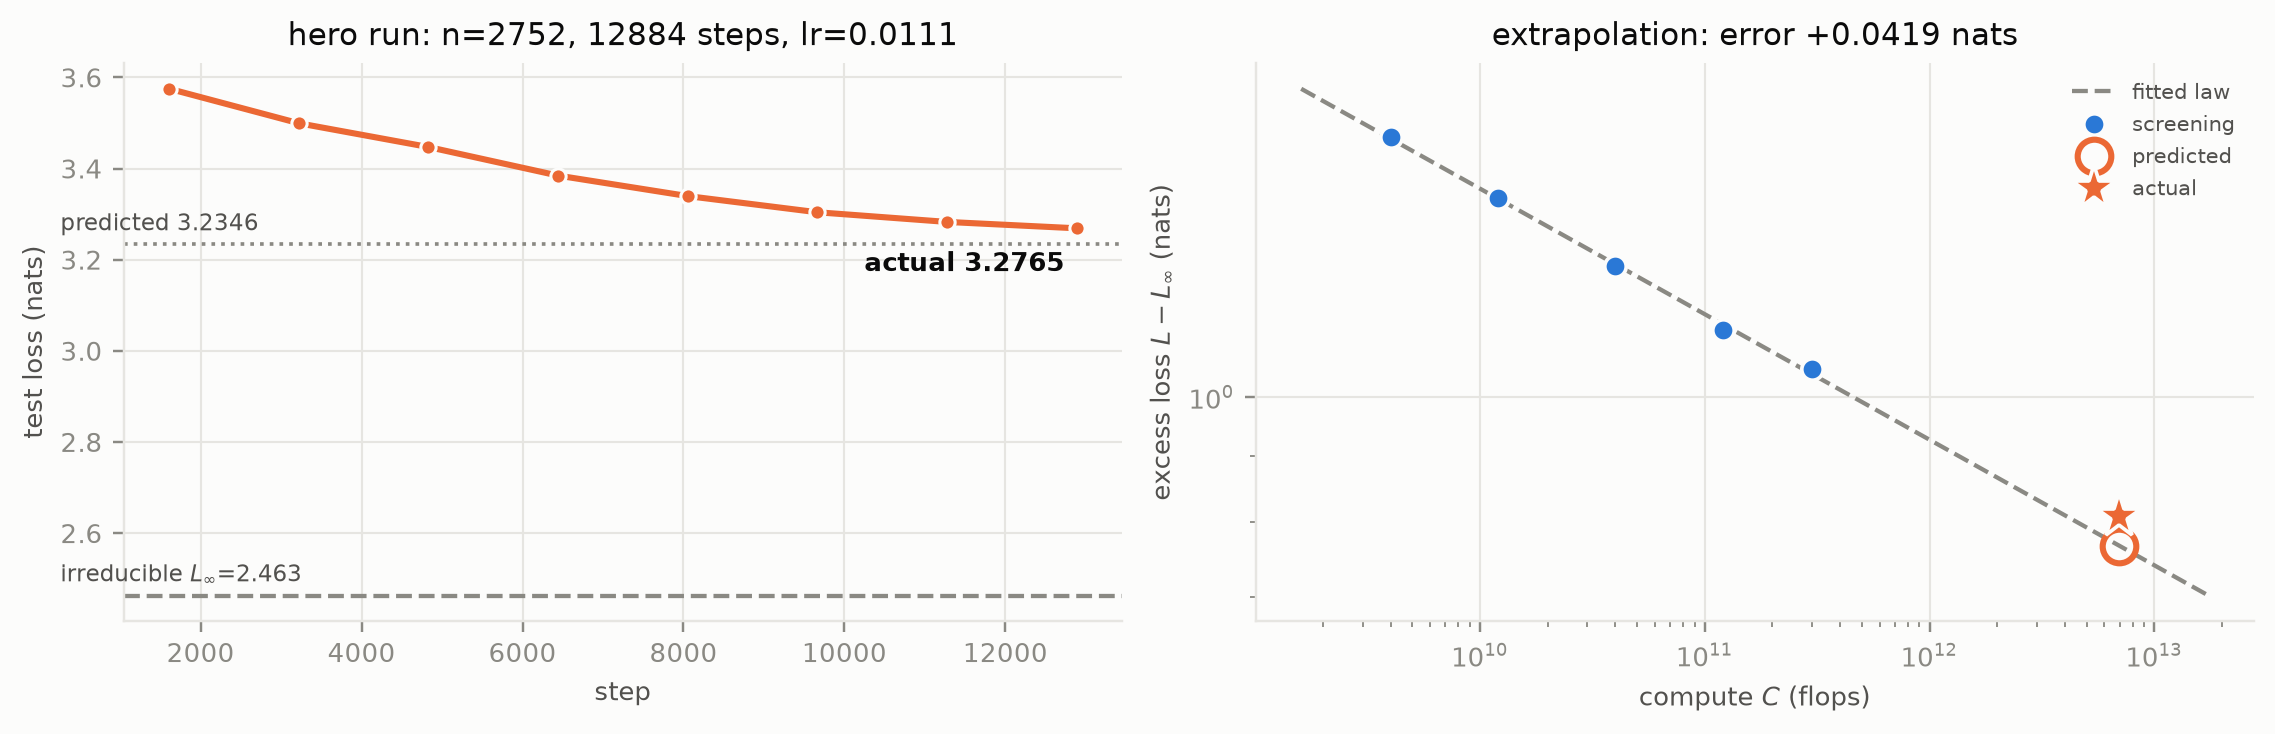

In [12]:
hero = lab.hero(laws)

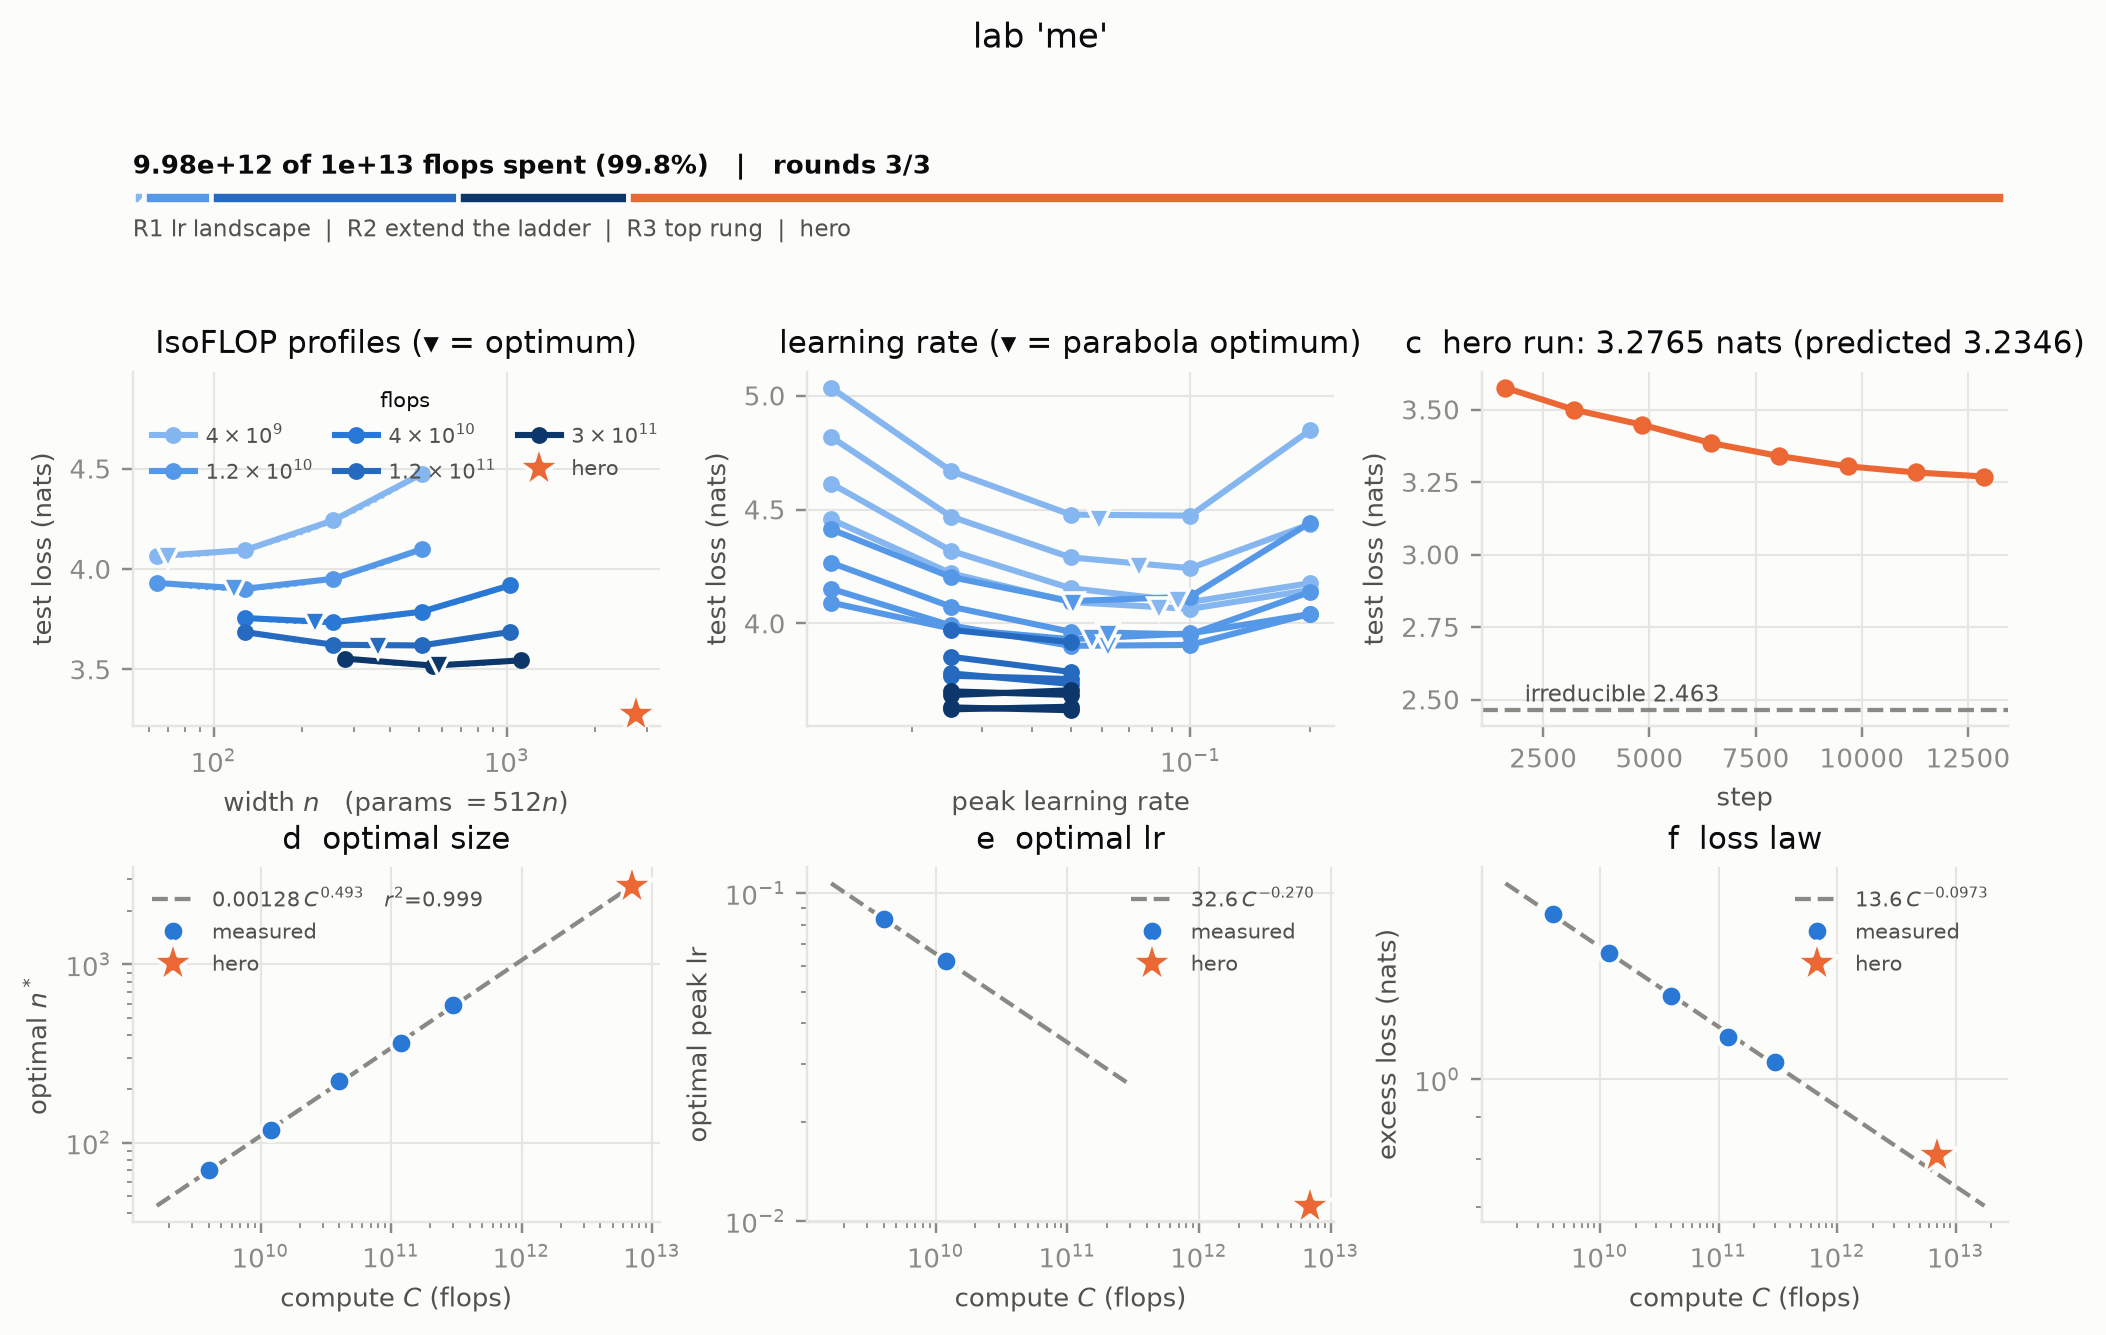

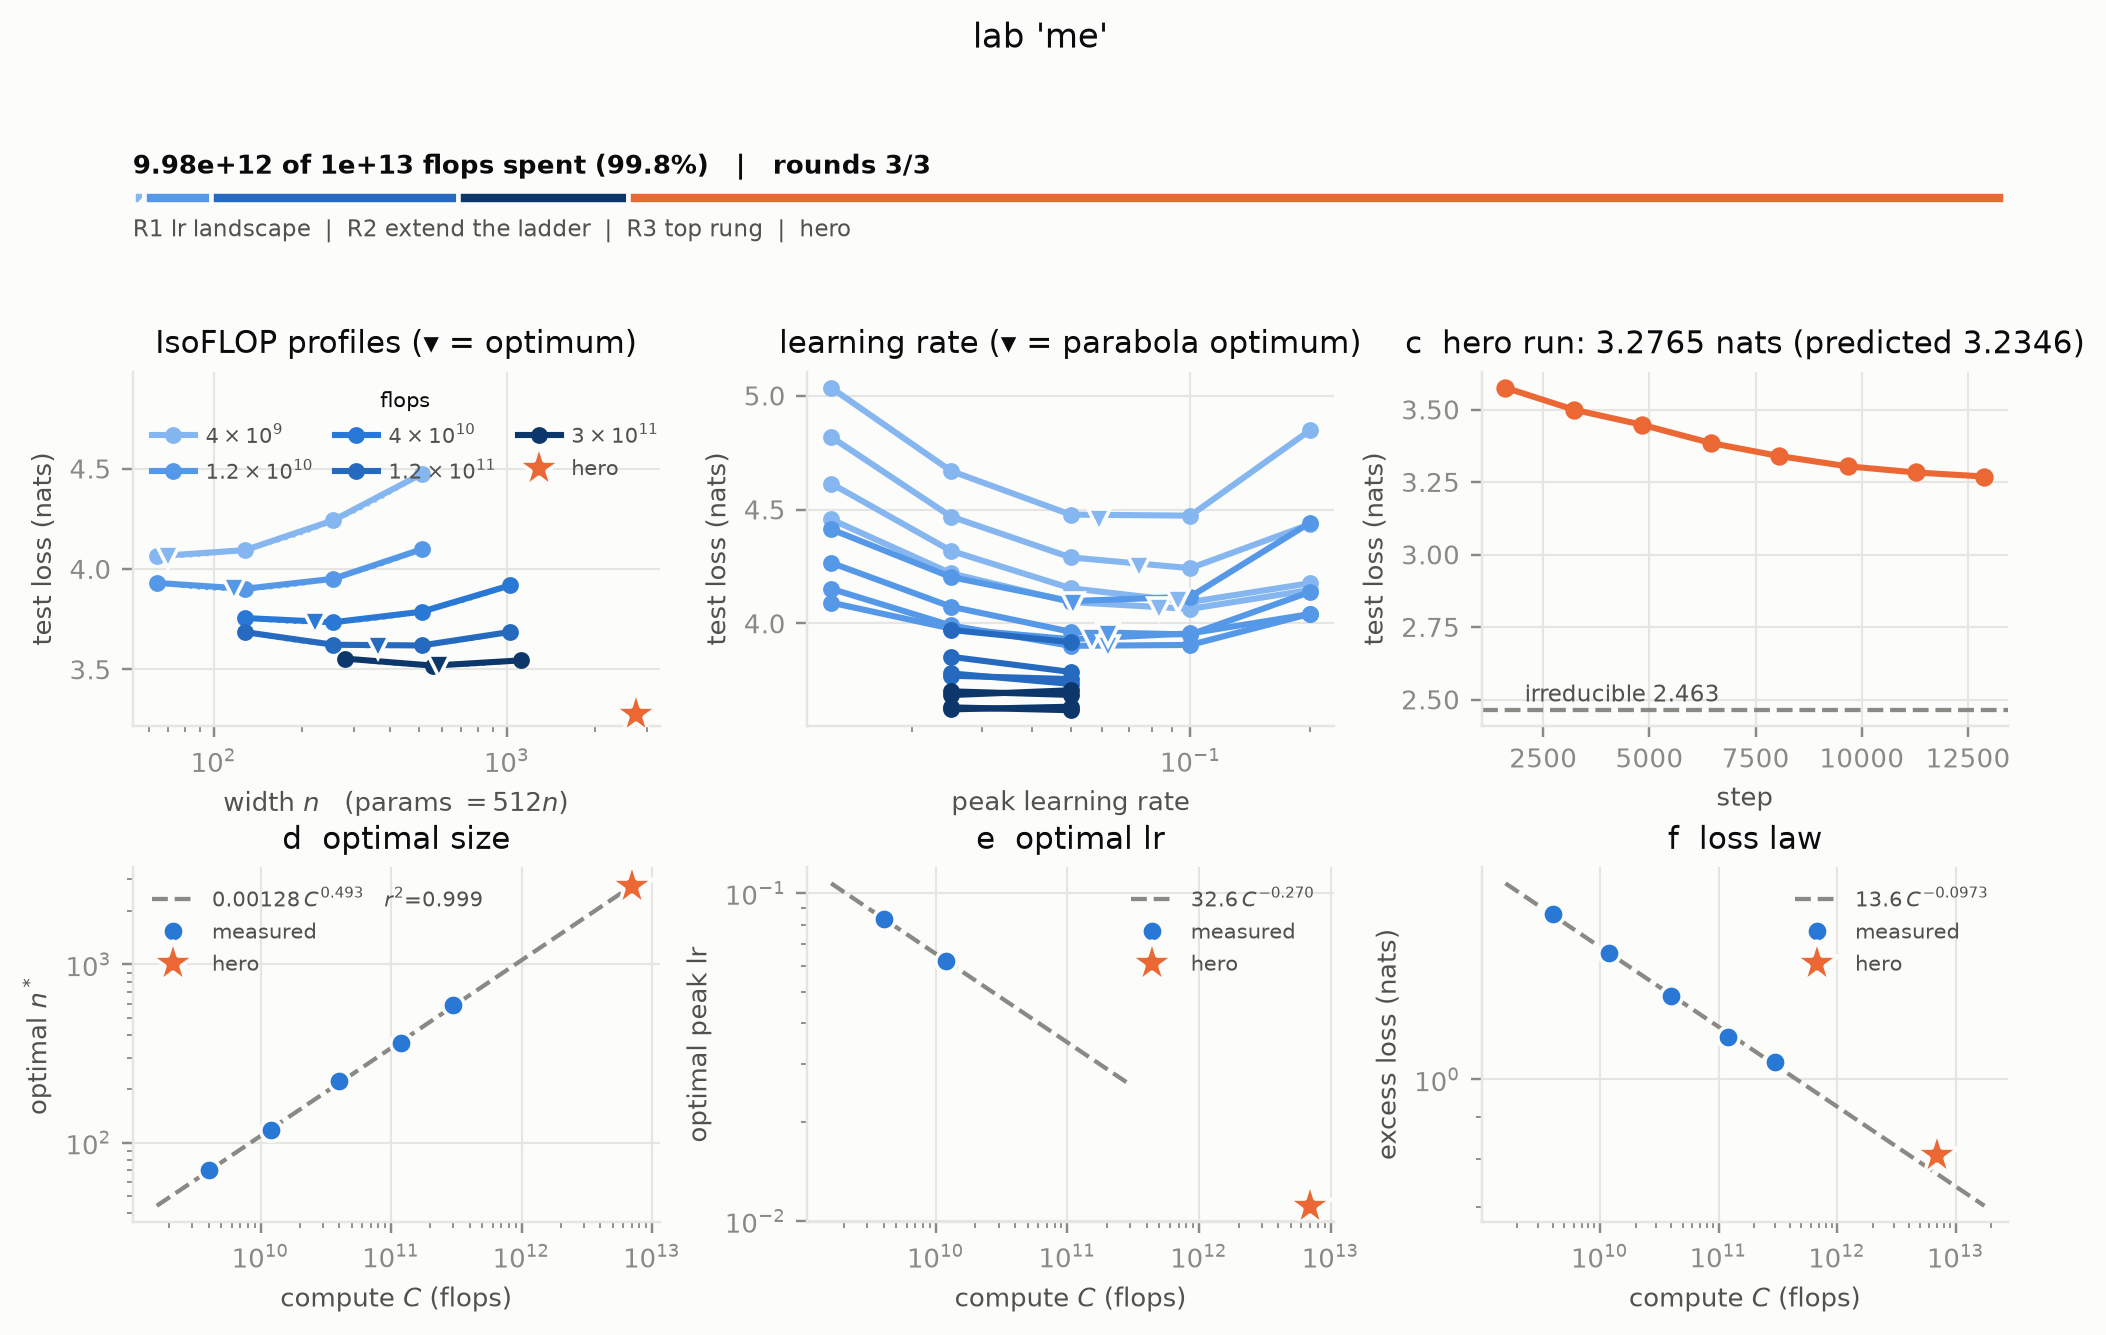

In [13]:
plot_summary(lab, laws)

## 7. Write it up

One page:

1. **Recipe** — the three laws, with $r^2$, and how you split your budget across rounds.
2. **Hero-run parameters** — `n`, steps, tokens, `lr`, and the flops it used.
3. **Expected loss** — what you predicted, and your uncertainty on it.
4. **Actual loss** — what you got, and *why the difference has the sign it does*.

Things worth commenting on:

* Your compute split $N\propto C^{b}$, $D\propto C^{1-b}$. How does $b$ compare to 0.5? How many
  tokens per parameter did your hero run use — and how does that compare to the ~20 of LLM
  scaling laws? Why is this problem in the opposite regime?
* The excess loss $L-L_\infty$ decays *very* slowly in $C$. Can you explain that from the Zipf
  tail? (Hint: if a model can memorise the top $K$ tokens, the mass it gets wrong is
  $\sum_{x>K}p(x)\propto K^{-(\gamma-1)}$ with $\gamma=1.2$ — a tiny exponent. What does that
  imply for $n^*\propto C^{1/(1+\gamma)}$?)

### The one number that matters most

Two reference attempts at this exercise:

| attempt | spent on tuning | law quality | hero loss |
|---|---|---|---|
| careful: 5 rungs, lr parabola at the top rung | 47 % | $r^2=0.9992$, prediction error +0.032 | **3.2993** |
| the mediocre defaults in this notebook | 26 % | $r^2=0.9983$, prediction error +0.042 | **3.2765** |

**The sloppier one won.** Because $\alpha\approx0.097$, the loss barely moves with compute — but
it moves *monotonically*, and every flop you spend on screening is a flop the hero run does not
get. Meanwhile the IsoFLOP minimum is flat enough that a mediocre estimate of $n^*$ costs you
almost nothing.

So the real skill here is not fitting the prettiest law. It is **fitting a law that is just good
enough, as cheaply as possible.** The total spread between a careless attempt and a perfect one
is only about 0.05 nats — say so in your write-up, with an error bar. Getting the *sign* of your
prediction error right, and knowing why, is worth more than the fourth decimal place.